In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import tensorflow as tf

# 1. Baixa a versão oficial do dataset de pneumonia do Kaggle para a máquina do Colab
print("Baixando dataset do Kaggle... Isso pode levar alguns segundos.")
path_dataset = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset baixado com sucesso para o diretório:", path_dataset)

# 2. Mapeia a pasta interna correta do dataset (onde ficam as pastas train e val)
data_dir = os.path.join(path_dataset, "chest_xray")
print(f"Diretório raiz das imagens configurado: {data_dir}")

Baixando dataset do Kaggle... Isso pode levar alguns segundos.
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset baixado com sucesso para o diretório: /kaggle/input/chest-xray-pneumonia
Diretório raiz das imagens configurado: /kaggle/input/chest-xray-pneumonia/chest_xray


In [2]:
from google.colab import files
import io

print("Por favor, selecione os arquivos 'train.csv' e 'val.csv' do seu computador:")
# Abre a janela física do sistema para você selecionar os arquivos da pasta 'data/splits/' do seu Git
uploaded = files.upload()

# Carrega os arquivos na memória usando o Pandas
if 'train.csv' in uploaded and 'val.csv' in uploaded:
    train_df = pd.read_csv(io.BytesIO(uploaded['train.csv']))
    val_df = pd.read_csv(io.BytesIO(uploaded['val.csv']))
    print("\n[SUCESSO] Arquivos carregados na memória do Pandas!")
    print(f"Total de registros de treino: {len(train_df)}")
    print(f"Total de registros de validação: {len(val_df)}")
    print("\nEstrutura de colunas detectada:", train_df.columns.tolist())
else:
    print("\n[ERRO] Certifique-se de selecionar AMBOS os arquivos (train.csv e val.csv) juntos.")

Por favor, selecione os arquivos 'train.csv' e 'val.csv' do seu computador:


Saving train.csv to train.csv
Saving val.csv to val.csv

[SUCESSO] Arquivos carregados na memória do Pandas!
Total de registros de treino: 4677
Total de registros de validação: 555

Estrutura de colunas detectada: ['filepath', 'label', 'subtipo', 'person_id']


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configura os geradores para reescalar os pixels de 0-255 para 0-1
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Conecta os caminhos do CSV com o diretório real das imagens físicas
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=data_dir,      # Variável que aponta para as imagens extraídas pelo KaggleHub
    x_col='filepath',        # Nome exato da coluna encontrada no CSV do grupo
    y_col='label',           # Coluna contendo as classes (NORMAL / PNEUMONIA)
    target_size=(224, 224),  # VGG16 exige imagens 224x224
    color_mode='rgb',        # VGG16 exige 3 canais (RGB)
    class_mode='binary',     # Classificação binária
    batch_size=32,
    shuffle=True             # Embaralha os dados de treino
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=data_dir,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=32,
    shuffle=False            # Validação NUNCA deve ser embaralhada
)

print("\n[VERIFICAÇÃO DE SUCESSO]:")
print(f"Quantidade de batches no treino: {len(train_generator)}")
print(f"Quantidade de batches na validação: {len(val_generator)}")

Found 4677 validated image filenames belonging to 2 classes.
Found 555 validated image filenames belonging to 2 classes.

[VERIFICAÇÃO DE SUCESSO]:
Quantidade de batches no treino: 147
Quantidade de batches na validação: 18


In [4]:
from tensorflow.keras import layers, models

def criar_modelo_vgg16_cardioia(input_shape=(224, 224, 3)):
    # 1. Importa a VGG16 pré-treinada na ImageNet removendo as camadas densas superiores (top)
    base_model = tf.keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # 2. Congela os pesos das camadas convolucionais da VGG16 original
    base_model.trainable = False

    # 3. Adiciona a nova cabeça de classificação personalizada do CardioIA
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5) (x)  # Dropout para controle de overfitting

    # Camada final binária com ativação Sigmoid
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

# Instancia e compila o modelo
model_vgg16 = criar_modelo_vgg16_cardioia()
model_vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# Exibe o resumo estrutural na tela
model_vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configura as travas para parar se o modelo parar de evoluir e salvar o melhor resultado
callbacks_list = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,                 # Interrompe se a val_loss não cair por 3 épocas seguidas
        restore_best_weights=True   # Restaura os pesos da melhor época atingida
    ),
    ModelCheckpoint(
        filepath='vgg16_finetuned.keras', # O arquivo que você vai baixar para o GitHub Releases!
        monitor='val_loss',
        save_best_only=True         # Apenas sobrescreve se o resultado na validação melhorar
    )
]

print("Iniciando o treinamento com Transfer Learning (VGG16)...")
epochs = 10

history = model_vgg16.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks_list
)

print("\n[SUCESSO] Treinamento concluído! O arquivo 'vgg16_finetuned.keras' foi salvo com sucesso.")

Iniciando o treinamento com Transfer Learning (VGG16)...
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 104s 603ms/step - accuracy: 0.7148 - loss: 0.5714 - precision: 0.7514 - recall: 0.9189 - val_accuracy: 0.7568 - val_loss: 0.4494 - val_precision: 0.7568 - val_recall: 1.0000
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 56s 379ms/step - accuracy: 0.7817 - loss: 0.4446 - precision: 0.7815 - recall: 0.9789 - val_accuracy: 0.8523 - val_loss: 0.3678 - val_precision: 0.8407 - val_recall: 0.9929
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 56s 384ms/step - accuracy: 0.8399 - loss: 0.3656 - precision: 0.8396 - recall: 0.9688 - val_accuracy: 0.8937 - val_loss: 0.3078 - val_precision: 0.9112 - val_recall: 0.9524
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 57s 387ms/step - accuracy: 0.8717 - loss: 0.3125 - precision: 0.8780 - recall: 0.9602 - val_accuracy: 0.9027 - val_loss: 0.2717 - val_precision: 0.9336 - val_recall: 0.9381
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 58s 393ms/step - accuracy: 0.8884 - loss: 0.2795 -

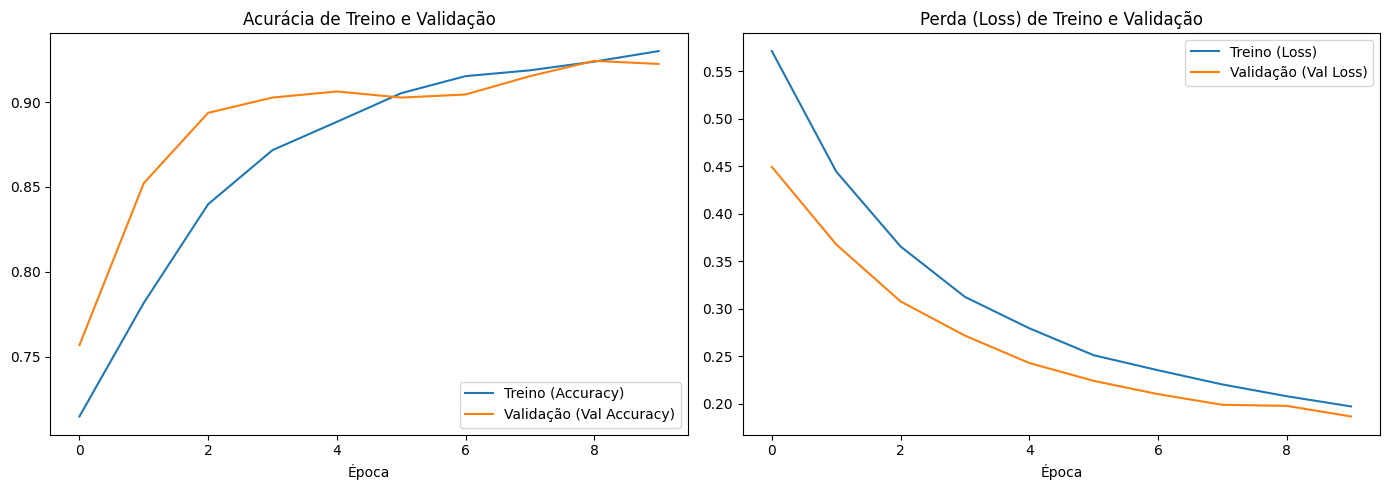


Calculando métricas finais no conjunto de validação...
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 468ms/step


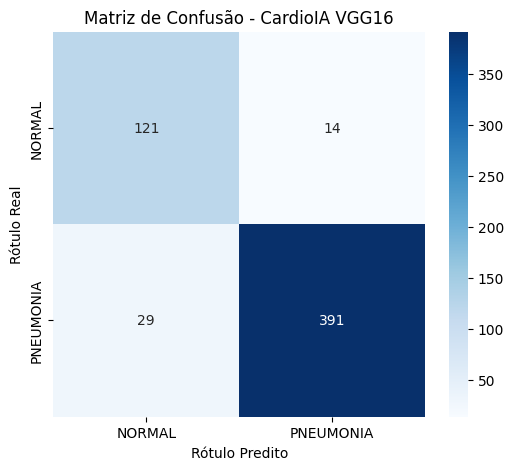


Relatório Técnico de Classificação:
              precision    recall  f1-score   support

      NORMAL       0.81      0.90      0.85       135
   PNEUMONIA       0.97      0.93      0.95       420

    accuracy                           0.92       555
   macro avg       0.89      0.91      0.90       555
weighted avg       0.93      0.92      0.92       555


Gerando explicabilidade visual (GRAD-CAM)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


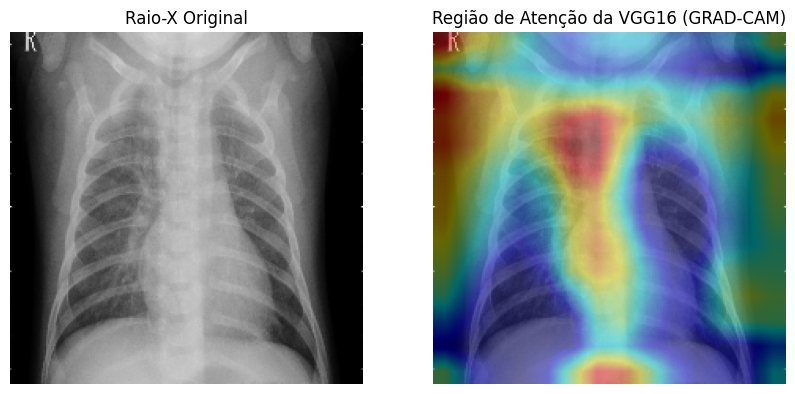

In [7]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. PARTE: GRÁFICOS DE DESEMPENHO (Loss/Acc)
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino (Accuracy)')
plt.plot(epochs_range, val_acc, label='Validação (Val Accuracy)')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Época')

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino (Loss)')
plt.plot(epochs_range, val_loss, label='Validação (Val Loss)')
plt.legend(loc='upper right')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Época')

plt.tight_layout()
plt.show()

# ==========================================
# 2. PARTE: MATRIZ DE CONFUSÃO E MÉTRICAS
# ==========================================
print("\nCalculando métricas finais no conjunto de validação...")
val_generator.reset()

# Predições binárias (0 ou 1)
predictions = model_vgg16.predict(val_generator)
pred_labels = (predictions > 0.5).astype(int).flatten()

true_labels = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Matriz de Confusão
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CardioIA VGG16')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Predito')
plt.show()

print("\nRelatório Técnico de Classificação:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# ==========================================
# 3. PARTE: EXPLICABILIDADE VISUAL (GRAD-CAM)
# ==========================================
print("\nGerando explicabilidade visual (GRAD-CAM)...")

def mapear_gradcam(model, img_array, layer_name="block5_conv3"):
    grad_model = models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    guided_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    guided_grads = guided_grads.numpy()

    cam = np.zeros(conv_outputs.shape[0:2], dtype=np.float32)
    for i, w in enumerate(guided_grads):
        cam += w * conv_outputs[:, :, i]

    cam = np.maximum(cam, 0)
    cam /= np.max(cam) if np.max(cam) != 0 else 1
    cam = cv2.resize(cam, (224, 224))
    return cam

def plotar_resultado_gradcam(img_path, cam):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    output_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Raio-X Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title("Região de Atenção da VGG16 (GRAD-CAM)")
    plt.axis('off')
    plt.show()

# Pega uma imagem de teste do CSV para aplicar o mapa
exemplo_pneumonia = val_df[val_df['label'] == 'PNEUMONIA'].iloc[0]['filepath']
caminho_completo_foto = os.path.join(data_dir, exemplo_pneumonia)

img_teste = tf.keras.utils.load_img(caminho_completo_foto, target_size=(224, 224))
img_teste_arr = tf.keras.utils.img_to_array(img_teste) / 255.0
img_teste_arr = np.expand_dims(img_teste_arr, axis=0)
img_teste_tensor = tf.convert_to_tensor(img_teste_arr)

mapa_calor = mapear_gradcam(model_vgg16, img_teste_tensor, layer_name="block5_conv3")
plotar_resultado_gradcam(caminho_completo_foto, mapa_calor)